Name - Sarthak Balaji Zunjure

PRN NO- 1252090003

roll no - 03

Assignemnt 5 :- Predict the price of the Uber ride from a given pickup point to the agreed drop-off location. Perform following tasks: 1. Pre-process the dataset. 2. Identify outliers. 3. Check the correlation. 4. Implement linear regression and ridge, Lasso regression models. 5. Evaluate the models and compare their respective scores like R2, RMSE, etc. Dataset link: https://www.kaggle.com/datasets/yasserh/uber-fares-dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error
df = pd.read_csv("uber.csv")
df.head()


,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


Step 1: Data Pre-Processing

In [ ]:
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


,0
Unnamed: 0,0
key,0
fare_amount,0
pickup_datetime,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,1
dropoff_latitude,1
passenger_count,0


Remove missing values

In [ ]:
df.dropna(inplace=True)

2.2 Convert pickup_datetime & extract features

In [ ]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

df['hour'] = df['pickup_datetime'].dt.hour
df['day'] = df['pickup_datetime'].dt.day
df['month'] = df['pickup_datetime'].dt.month
df['year'] = df['pickup_datetime'].dt.year


2.3 Remove unnecessary columns

In [ ]:
df.drop(['pickup_datetime', 'key'], axis=1, inplace=True)


2.4 Remove invalid fare values (data cleaning)

In [ ]:
df = df[(df['fare_amount'] > 0) & (df['fare_amount'] < 500)]

Step 3: Identify Outliers
(Box Plot – Univariate Analysis)

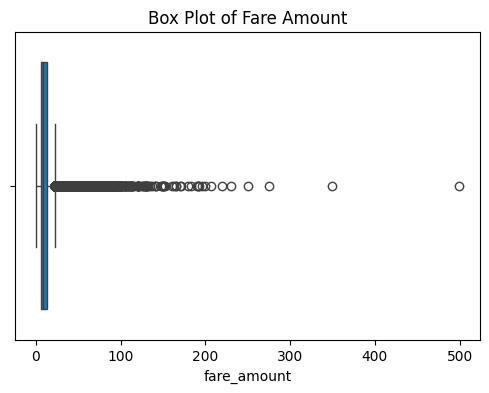

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['fare_amount'])
plt.title("Box Plot of Fare Amount")
plt.show()


Step 4: Correlation Analysis

4.1 Default correlation

In [ ]:
df.corr()


,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,year
Unnamed: 0,1.000000,0.000614,0.000198,-0.000315,0.000297,0.000243,0.002246,0.000035,0.000546,0.001306,-0.001329
fare_amount,0.000614,1.000000,0.010468,-0.008489,0.009208,-0.011250,0.010422,-0.021457,0.001336,0.023564,0.118531
pickup_longitude,0.000198,0.010468,1.000000,-0.816434,0.833132,-0.846449,-0.000488,0.002463,0.005189,-0.004638,0.009921
pickup_latitude,-0.000315,-0.008489,-0.816434,1.000000,-0.774880,0.702450,-0.001500,-0.003847,-0.008268,0.004604,-0.010197
dropoff_longitude,0.000297,0.009208,0.833132,-0.774880,1.000000,-0.916971,-0.000104,0.003527,0.005075,-0.003504,0.008330
dropoff_latitude,0.000243,-0.011250,-0.846449,0.702450,-0.916971,1.000000,-0.000514,-0.002597,-0.007857,0.003711,-0.011094
passenger_count,0.002246,0.010422,-0.000488,-0.001500,-0.000104,-0.000514,1.000000,0.013203,0.003233,0.009826,0.004790
hour,0.000035,-0.021457,0.002463,-0.003847,0.003527,-0.002597,0.013203,1.000000,0.004658,-0.003931,0.002150
day,0.000546,0.001336,0.005189,-0.008268,0.005075,-0.007857,0.003233,0.004658,1.000000,-0.017387,-0.012119
month,0.001306,0.023564,-0.004638,0.004604,-0.003504,0.003711,0.009826,-0.003931,-0.017387,1.000000,-0.115832


4.2 Pearson Correlation (Linear)

In [ ]:
df.corr(method='pearson')


,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,year
Unnamed: 0,1.000000,0.000614,0.000198,-0.000315,0.000297,0.000243,0.002246,0.000035,0.000546,0.001306,-0.001329
fare_amount,0.000614,1.000000,0.010468,-0.008489,0.009208,-0.011250,0.010422,-0.021457,0.001336,0.023564,0.118531
pickup_longitude,0.000198,0.010468,1.000000,-0.816434,0.833132,-0.846449,-0.000488,0.002463,0.005189,-0.004638,0.009921
pickup_latitude,-0.000315,-0.008489,-0.816434,1.000000,-0.774880,0.702450,-0.001500,-0.003847,-0.008268,0.004604,-0.010197
dropoff_longitude,0.000297,0.009208,0.833132,-0.774880,1.000000,-0.916971,-0.000104,0.003527,0.005075,-0.003504,0.008330
dropoff_latitude,0.000243,-0.011250,-0.846449,0.702450,-0.916971,1.000000,-0.000514,-0.002597,-0.007857,0.003711,-0.011094
passenger_count,0.002246,0.010422,-0.000488,-0.001500,-0.000104,-0.000514,1.000000,0.013203,0.003233,0.009826,0.004790
hour,0.000035,-0.021457,0.002463,-0.003847,0.003527,-0.002597,0.013203,1.000000,0.004658,-0.003931,0.002150
day,0.000546,0.001336,0.005189,-0.008268,0.005075,-0.007857,0.003233,0.004658,1.000000,-0.017387,-0.012119
month,0.001306,0.023564,-0.004638,0.004604,-0.003504,0.003711,0.009826,-0.003931,-0.017387,1.000000,-0.115832


4.3 Spearman Correlation (Monotonic)

In [ ]:
df.corr(method='spearman')


,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,year
Unnamed: 0,1.000000,0.000690,0.003190,0.002967,0.006631,0.002636,0.003304,-0.000140,0.000535,0.001459,-0.001348
fare_amount,0.000690,1.000000,0.042781,-0.073563,0.102437,-0.086549,0.023402,-0.006214,0.004667,0.031531,0.149092
pickup_longitude,0.003190,0.042781,1.000000,0.513387,0.403620,0.215540,-0.016181,0.001503,-0.003773,-0.001104,0.006237
pickup_latitude,0.002967,-0.073563,0.513387,1.000000,0.196919,0.497912,-0.015730,0.012174,-0.001273,0.001676,-0.010703
dropoff_longitude,0.006631,0.102437,0.403620,0.196919,1.000000,0.466249,-0.012870,-0.032167,-0.006377,0.000129,0.008880
dropoff_latitude,0.002636,-0.086549,0.215540,0.497912,0.466249,1.000000,-0.008695,0.001295,-0.005110,-0.000640,-0.008038
passenger_count,0.003304,0.023402,-0.016181,-0.015730,-0.012870,-0.008695,1.000000,0.034652,0.001468,0.009574,-0.012310
hour,-0.000140,-0.006214,0.001503,0.012174,-0.032167,0.001295,0.034652,1.000000,0.005722,-0.003002,0.002480
day,0.000535,0.004667,-0.003773,-0.001273,-0.006377,-0.005110,0.001468,0.005722,1.000000,-0.017077,-0.012086
month,0.001459,0.031531,-0.001104,0.001676,0.000129,-0.000640,0.009574,-0.003002,-0.017077,1.000000,-0.108653


4.4 Kendall Correlation (Rank-based)

In [ ]:
df.corr(method='kendall')


,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,year
Unnamed: 0,1.000000,0.000460,0.002129,0.001978,0.004420,0.001754,0.002564,-0.000095,0.000361,0.001009,-0.000964
fare_amount,0.000460,1.000000,0.027645,-0.051093,0.069142,-0.059982,0.018304,-0.003951,0.003195,0.022085,0.107760
pickup_longitude,0.002129,0.027645,1.000000,0.397314,0.283640,0.152560,-0.012557,0.000286,-0.002559,-0.000770,0.004447
pickup_latitude,0.001978,-0.051093,0.397314,1.000000,0.139885,0.357188,-0.012201,0.007947,-0.000863,0.001169,-0.007645
dropoff_longitude,0.004420,0.069142,0.283640,0.139885,1.000000,0.366087,-0.009961,-0.021845,-0.004323,0.000087,0.006317
dropoff_latitude,0.001754,-0.059982,0.152560,0.357188,0.366087,1.000000,-0.006741,0.001364,-0.003472,-0.000438,-0.005754
passenger_count,0.002564,0.018304,-0.012557,-0.012201,-0.009961,-0.006741,1.000000,0.027474,0.001153,0.007729,-0.010191
hour,-0.000095,-0.003951,0.000286,0.007947,-0.021845,0.001364,0.027474,1.000000,0.003966,-0.002127,0.001819
day,0.000361,0.003195,-0.002559,-0.000863,-0.004323,-0.003472,0.001153,0.003966,1.000000,-0.012015,-0.008780
month,0.001009,0.022085,-0.000770,0.001169,0.000087,-0.000438,0.007729,-0.002127,-0.012015,1.000000,-0.080730


Correlation Heatmap

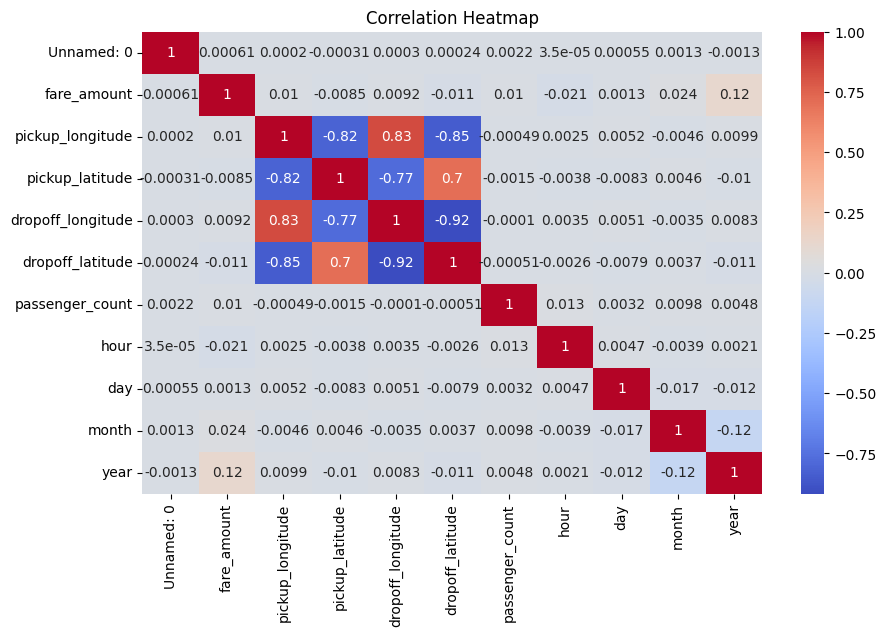

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


Step 5: Feature Selection & Train-Test Split

In [ ]:
X = df.drop('fare_amount', axis=1)
y = df['fare_amount']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Step 6: Feature Scaling

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Step 7: Implement Regression Models

7.1 Linear Regression

In [ ]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)


7.2 Ridge Regression

In [ ]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)


7.3 Lasso Regression

In [ ]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)


Step 8: Model Evaluation & Comparison

Evaluation function

In [ ]:
def evaluate_model(y_true, y_pred, model_name):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{model_name}")
    print(f"R2 Score: {r2:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print("------------------------")


Evaluate all models

In [ ]:
evaluate_model(y_test, y_pred_lr, "Linear Regression")
evaluate_model(y_test, y_pred_ridge, "Ridge Regression")
evaluate_model(y_test, y_pred_lasso, "Lasso Regression")


Linear Regression
R2 Score: 0.016
RMSE: 9.567
------------------------
Ridge Regression
R2 Score: 0.016
RMSE: 9.567
------------------------
Lasso Regression
R2 Score: 0.015
RMSE: 9.569
------------------------
